## Volatility Targeting


Harvey, C. R. (with Rattray, S., & Hemert, O. van) have one section to discuss this topic in their book Strategic Risk Management: Designing Portfolios and Managing Risk. John Wiley & Sons, Incorporated.

This is heavily inspired what they implemented and tried in their book.


In short, this is to target to keep the volatility of the whole portfolio at a specific number or range instead of keep a fixed allocation in number of different assets.
For example, if your target volatility is 15%, if the current volatility is at 30%, you should sell your risky asset to lower the volatilty, vice versa. The goal is to manage the volatility to manage the risk.


Let use QQQ, BIL as an example


In [1]:
%matplotlib inline

In [2]:
from tiportfolio.helpers.data import Alpaca
import dotenv

dotenv.load_dotenv()

import os
alpaca = Alpaca(os.environ['ALPACA_API_KEY'], os.environ['ALPACA_API_SECRET'])

In [3]:
from tiportfolio.helpers.data import YFinance
import pandas as pd
from datetime import datetime

# Initialize data sources
yf = YFinance()

# Define symbols and date range
symbols = ["QQQ", "BIL"]
start_date = "2020-01-01"
end_date = "2024-12-31"

# Fetch stock data from Alpaca
stock_data_df = alpaca.query(symbols, start_date, end_date)

# Fetch VIX data from Yahoo Finance
vix_df = yf.query(["^VIX"], start_date, end_date)
vix_series = vix_df.set_index('date')['close']

# Prepare dataframes for each strategy
qqq_prices = stock_data_df[stock_data_df['symbol'] == 'QQQ'].copy()
bil_prices = stock_data_df[stock_data_df['symbol'] == 'BIL'].copy()

# Ensure we have common dates
# vix_series.index might have timezone info or not, need to be careful with intersection
vix_series.index = pd.to_datetime(vix_series.index).tz_localize(None)
qqq_prices['date'] = pd.to_datetime(qqq_prices['date']).dt.tz_localize(None)
bil_prices['date'] = pd.to_datetime(bil_prices['date']).dt.tz_localize(None)

common_dates = set(qqq_prices['date']).intersection(set(bil_prices['date'])).intersection(set(vix_series.index))
common_dates = sorted(list(common_dates))

qqq_prices = qqq_prices[qqq_prices['date'].isin(common_dates)].set_index('date')
bil_prices = bil_prices[bil_prices['date'].isin(common_dates)].set_index('date')
vix_series = vix_series[vix_series.index.isin(common_dates)]

Loading bar data...
Loaded bar data: 0:00:02 

Loading bar data...


[*********************100%***********************]  1 of 1 completed

Loaded bar data: 0:00:01 



INFO:default_logger:Initialized Allocation with 1 strategies with initial capital 100000.0. 
INFO:default_logger: - Strategy: LongHold - QQQ
INFO:default_logger:Starting walk-forward allocation process...
  0%|          | 0/1257 [00:00<?, ?it/s]DEBUG:default_logger:At 2020-01-02 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-03 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-06 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-07 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-08 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-09 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-10 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default

Starting portfolio evaluation...


  0%|          | 0/1257 [00:00<?, ?it/s]DEBUG:default_logger:No rebalance at 2020-01-02 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-03 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-06 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-07 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-08 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-09 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-10 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-13 00:00:00, log overall trade data
DEBUG:defau

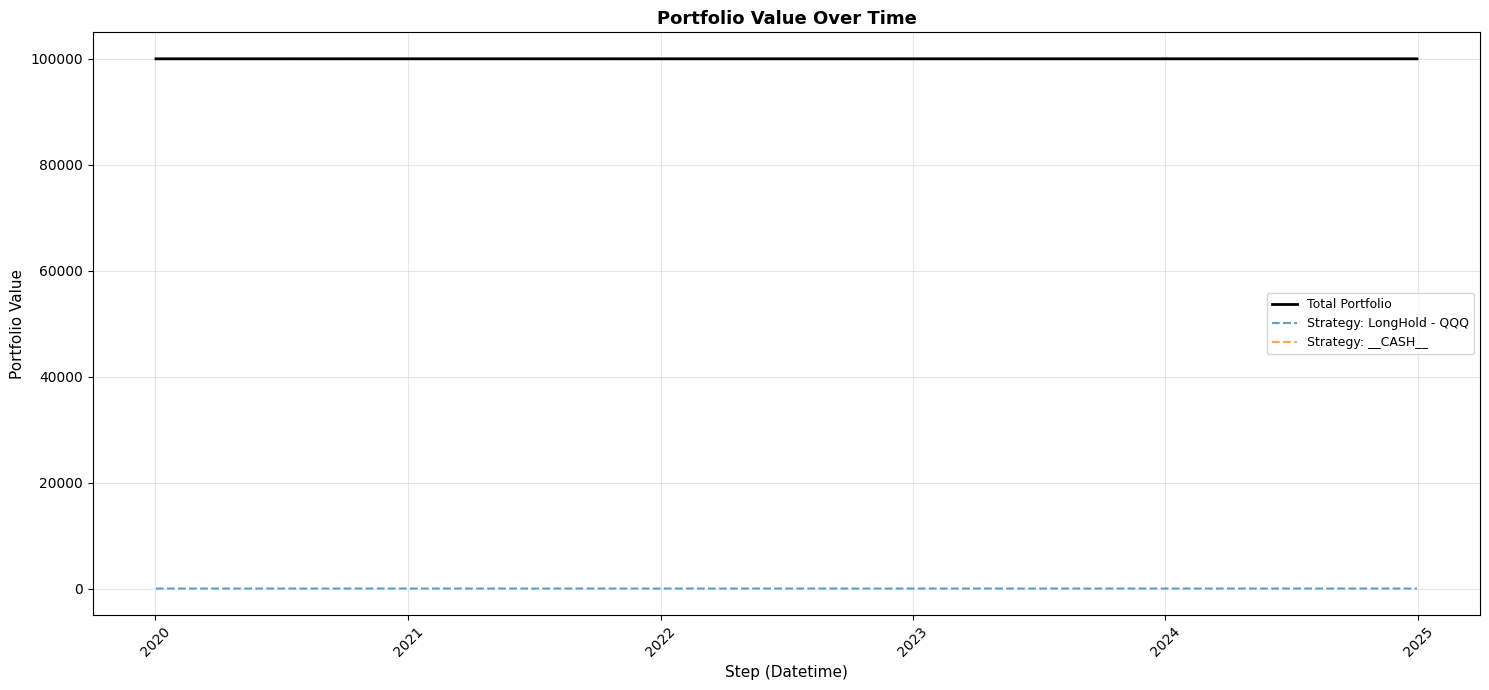

VIX Targeting Metrics (15% Target):
  final_value: 100000.0000
  total_return: 0.0000
  max_drawdown: 0.0000
  sharpe_ratio: 0.0000
  annualized_return: 0.0000
  mar_ratio: 0.0000


In [4]:
from tiportfolio.strategy_library.trading.long_hold import LongHold
from tiportfolio.portfolio.allocation.vix_targeting import VixTargetingAllocation
from tiportfolio.portfolio.allocation.frequency_based_allocation import RebalanceFrequency
from tiportfolio.portfolio.allocation.allocation import CASH_STRATEGY_NAME

# Create strategies
qqq_strategy = LongHold("QQQ", qqq_prices)
bil_strategy = LongHold("BIL", bil_prices)

# Configuration for the portfolio
config = {
    "initial_capital": 100000.0,
    "commission": 0.0001,  # 1bp
    "slippage": 0.0001,    # 1bp
    "risk_free_rate": 0.02,
    "market_name": "NYSE"
}

# 1. VIX Targeting Allocation (15% target)
vix_targeting = VixTargetingAllocation(
    config=config,
    strategies=[qqq_strategy], # We only target vol for QQQ
    vix_data=vix_series,
    target_vol=15.0,
    max_leverage=1.0,
    rebalance_frequency=RebalanceFrequency.daily
)

vix_targeting.walk_forward()
vix_targeting.evaluate()
metrics_vix = vix_targeting.get_performance_metrics(plot=True, fig_size=(15, 7))
print("VIX Targeting Metrics (15% Target):")
for k, v in metrics_vix.items():
    print(f"  {k}: {v:.4f}")

INFO:default_logger:Initialized Allocation with 1 strategies with initial capital 100000.0. 
INFO:default_logger: - Strategy: LongHold - QQQ
INFO:default_logger:Starting walk-forward allocation process...
  0%|          | 0/1257 [00:00<?, ?it/s]DEBUG:default_logger:At 2020-01-02 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-03 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-06 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-07 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-08 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-09 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default_logger:At 2020-01-10 00:00:00, Strategy LongHold - QQQ generated signal: TradingSignal.LONG
DEBUG:default

Starting portfolio evaluation...


  0%|          | 0/1257 [00:00<?, ?it/s]DEBUG:default_logger:No rebalance at 2020-01-02 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-03 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-06 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-07 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-08 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-09 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-10 00:00:00, log overall trade data
DEBUG:default_logger:Total value: 100000.0
DEBUG:default_logger:No rebalance at 2020-01-13 00:00:00, log overall trade data
DEBUG:defau

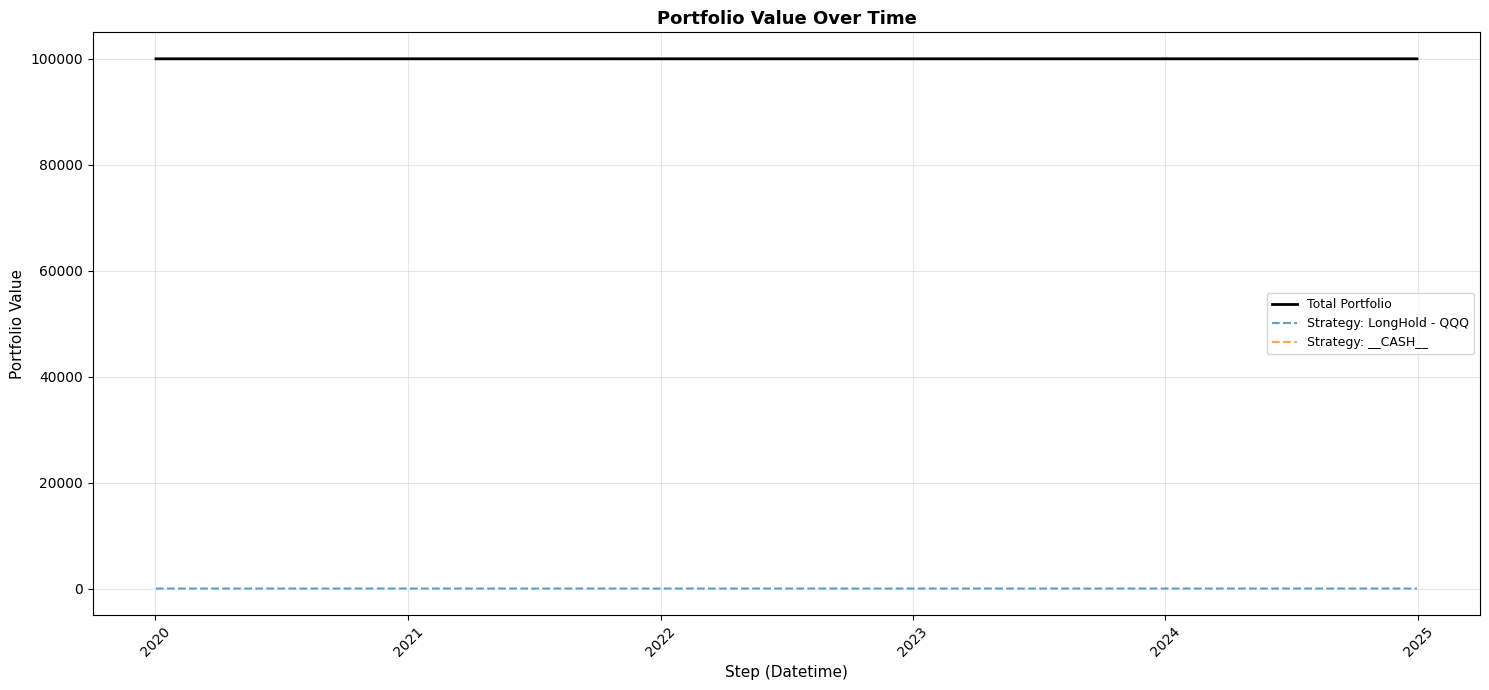

Benchmark (100% QQQ) Metrics:
  final_value: 100000.0000
  total_return: 0.0000
  max_drawdown: 0.0000
  sharpe_ratio: 0.0000
  annualized_return: 0.0000
  mar_ratio: 0.0000


In [5]:
# 2. Benchmark: 100% QQQ Allocation
from tiportfolio.strategy_library.allocation.fix_ratio import FixRatioFrequencyBasedAllocation

benchmark_allocation = FixRatioFrequencyBasedAllocation(
    config=config,
    strategies=[qqq_strategy],
    allocation_ratio_list=[1.0],
    rebalance_frequency=RebalanceFrequency.daily
)

benchmark_allocation.walk_forward()
benchmark_allocation.evaluate()
metrics_benchmark = benchmark_allocation.get_performance_metrics(plot=True, fig_size=(15, 7))
print("Benchmark (100% QQQ) Metrics:")
for k, v in metrics_benchmark.items():
    print(f"  {k}: {v:.4f}")

In [6]:
import matplotlib.pyplot as plt

print("\nComparison Summary:")
print(f"{'Metric':<20} | {'VIX Targeting':<15} | {'Benchmark':<15}")
print("-" * 55)
for k in metrics_vix.keys():
    print(f"{k:<20} | {metrics_vix[k]:<15.4f} | {metrics_benchmark[k]:<15.4f}")


Comparison Summary:
Metric               | VIX Targeting   | Benchmark      
-------------------------------------------------------
final_value          | 100000.0000     | 100000.0000    
total_return         | 0.0000          | 0.0000         
max_drawdown         | 0.0000          | 0.0000         
sharpe_ratio         | 0.0000          | 0.0000         
annualized_return    | 0.0000          | 0.0000         
mar_ratio            | 0.0000          | 0.0000         
